In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats  # For critical values


In [3]:
# ============================================
# 1. SETUP AND DATA PREPARATION
# ============================================

# Suppress warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv('STOXX50.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Select closing price series
ts = df['STOXX50_Close'].ffill()

# Split into train/test
test_size = 30
train_ts = ts[:-test_size]
test_ts = ts[-test_size:]

print("Training set:", len(train_ts), "days")
print("Test set:", len(test_ts), "days")

Training set: 4441 days
Test set: 30 days


In [ ]:
# ============================================
# 2. DETERMINE DIFFERENCING ORDER (d)
# ============================================

print("\n" + "="*60)
print("STEP 2: DETERMINING DIFFERENCING ORDER (d)")
print("="*60)

def check_stationarity(series, title):
    """Check if series is stationary using ADF test"""
    result = adfuller(series.dropna(), autolag='AIC')
    return result  # Return full result object

# Test original series
print("\nAUGMENTED DICKEY-FULLER TEST - Original Training Series:")
adf_result = check_stationarity(train_ts, "Original Series")

# Extract values from ADF result
adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lag = adf_result[2]
n_obs = adf_result[3]
critical_values = adf_result[4]

print(f"ADF Statistic: {adf_statistic:.6f}")
print(f"p-value: {p_value:.6f}")
print(f"Lags used: {used_lag}")
print(f"Number of observations: {n_obs}")
print("\nCritical Values:")
print(f"  1%: {critical_values['1%']:.6f}")
print(f"  5%: {critical_values['5%']:.6f}")
print(f"  10%: {critical_values['10%']:.6f}")

# Decision rule
print(f"\nDecision Rule:")
print(f"  If ADF Statistic < Critical Value (e.g., 5% = {critical_values['5%']:.6f}) and p-value < 0.05")
print(f"  → Series is stationary")
print(f"  If ADF Statistic > Critical Value and p-value > 0.05")
print(f"  → Series is non-stationary")

if p_value <= 0.05:
    print(f"\nDecision: p-value ({p_value:.4f}) ≤ 0.05 → Reject H₀ (unit root)")
    print(f"✓ Original series is STATIONARY (d=0)")
    d = 0
    current_series = train_ts.copy()
else:
    print(f"\nDecision: p-value ({p_value:.4f}) > 0.05 → Fail to reject H₀")
    print(f"✗ Original series is NON-STATIONARY")
    
    print("\nTesting first-order differencing...")
    # Test first difference
    first_diff = train_ts.diff().dropna()
    adf_result_first = check_stationarity(first_diff, "First Difference")
    
    adf_stat_first = adf_result_first[0]
    p_first = adf_result_first[1]
    critical_first = adf_result_first[4]
    
    print(f"\nADF Test - First Difference:")
    print(f"  ADF Statistic: {adf_stat_first:.6f}")
    print(f"  p-value: {p_first:.6f}")
    print(f"  Critical Value (5%): {critical_first['5%']:.6f}")
    
    if p_first <= 0.05:
        d = 1
        current_series = first_diff
        print(f"\nDecision: p-value ({p_first:.4f}) ≤ 0.05 → Reject H₀")
        print(f"✓ First difference makes series STATIONARY (d=1)")
    else:
        print(f"\nDecision: p-value ({p_first:.4f}) > 0.05 → Fail to reject H₀")
        print("Testing second-order differencing...")
        
        # Test second difference
        second_diff = first_diff.diff().dropna()
        adf_result_second = check_stationarity(second_diff, "Second Difference")
        
        adf_stat_second = adf_result_second[0]
        p_second = adf_result_second[1]
        critical_second = adf_result_second[4]
        
        print(f"\nADF Test - Second Difference:")
        print(f"  ADF Statistic: {adf_stat_second:.6f}")
        print(f"  p-value: {p_second:.6f}")
        print(f"  Critical Value (5%): {critical_second['5%']:.6f}")
        
        if p_second <= 0.05:
            d = 2
            current_series = second_diff
            print(f"\nDecision: p-value ({p_second:.4f}) ≤ 0.05 → Reject H₀")
            print(f"✓ Second difference makes series STATIONARY (d=2)")
        else:
            d = 1  # Default to first difference
            print(f"\nDecision: p-value ({p_second:.4f}) > 0.05 → Fail to reject H₀")
            print(f"✗ Series not fully stationary after 2 differences. Using d=1 as default")

print(f"\nFinal differencing order: d = {d}")



STEP 1: DETERMINING DIFFERENCING ORDER (d)

AUGMENTED DICKEY-FULLER TEST - Original Training Series:
ADF Statistic: -1.100951
p-value: 0.714693
Lags used: 1
Number of observations: 4439

Critical Values:
  1%: -3.431824
  5%: -2.862191
  10%: -2.567117

Decision Rule:
  If ADF Statistic < Critical Value (e.g., 5% = -2.862191) and p-value < 0.05
  → Series is stationary
  If ADF Statistic > Critical Value and p-value > 0.05
  → Series is non-stationary

Decision: p-value (0.7147) > 0.05 → Fail to reject H₀
✗ Original series is NON-STATIONARY

Testing first-order differencing...

ADF Test - First Difference:
  ADF Statistic: -68.981231
  p-value: 0.000000
  Critical Value (5%): -2.862191

Decision: p-value (0.0000) ≤ 0.05 → Reject H₀
✓ First difference makes series STATIONARY (d=1)

Final differencing order: d = 1



STEP 2: VISUALIZING TRAINING DATA BEFORE AND AFTER DIFFERENCING


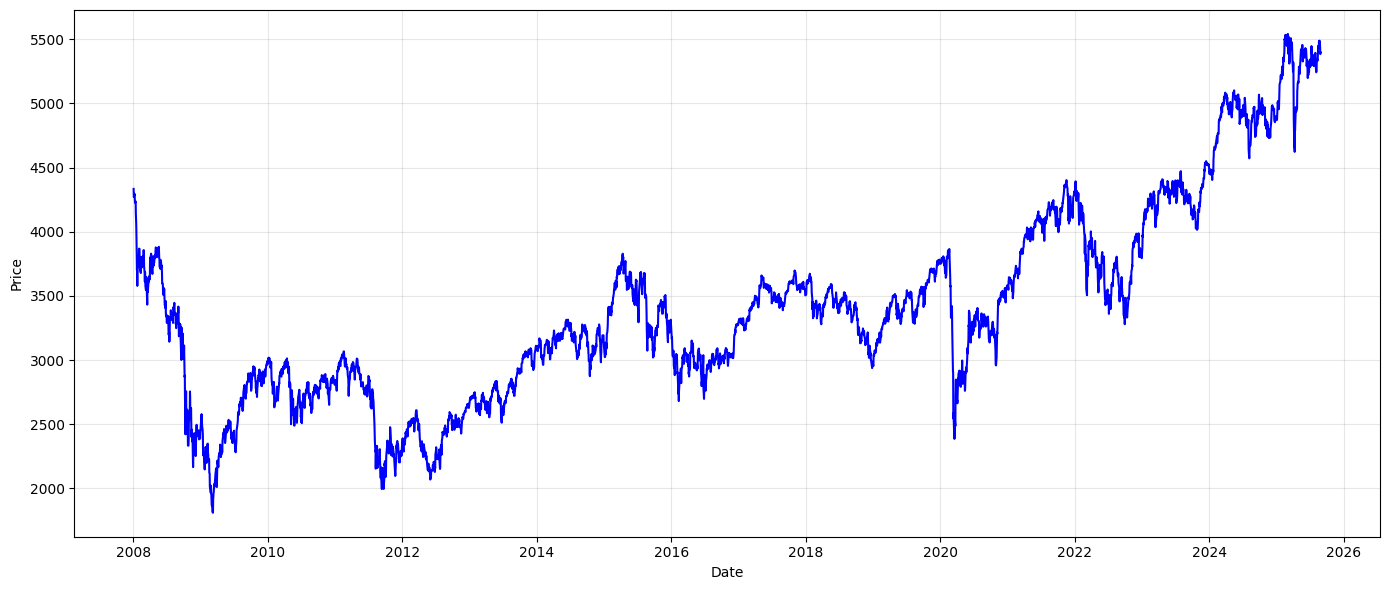

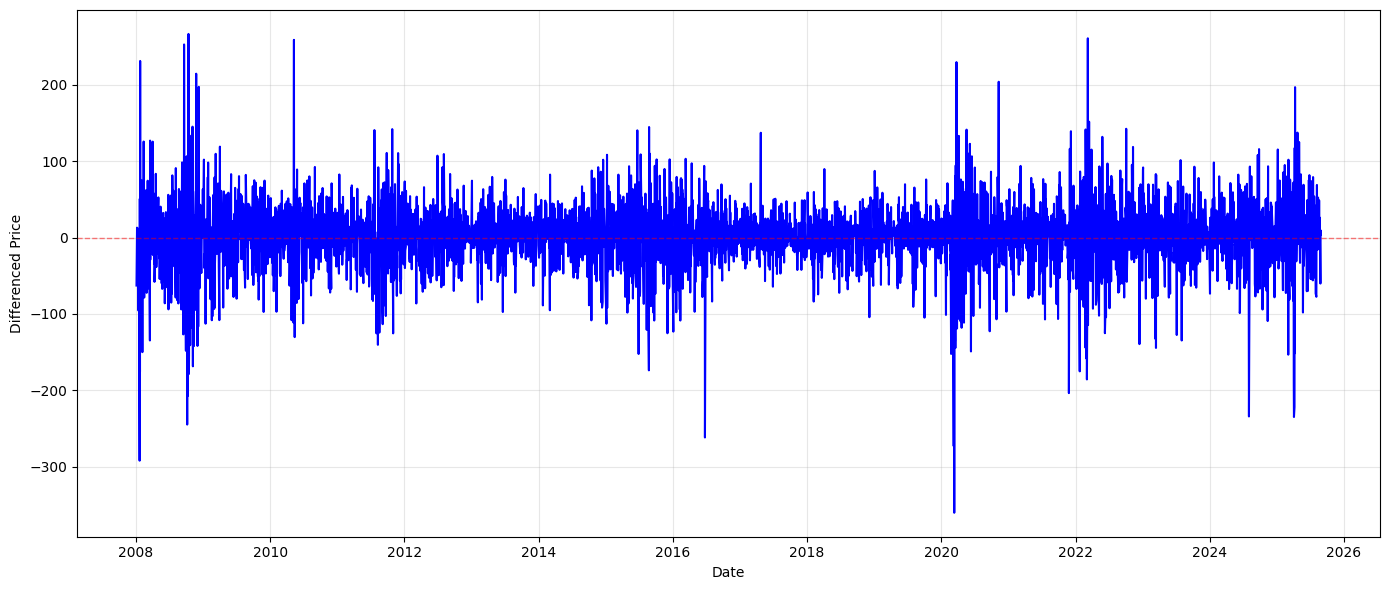


Statistics for Differenced Series (d=1):
  Mean: 0.2395
  Standard Deviation: 43.7162
  Min: -360.3301
  Max: 266.4500
  Range: 626.7800


In [ ]:
# ============================================
# 3. PLOT TRAINING SET BEFORE AND AFTER DIFFERENCING
# ============================================

print("\n" + "="*60)
print("STEP 3: VISUALIZING TRAINING DATA BEFORE AND AFTER DIFFERENCING")
print("="*60)

# PLOT 1: Training set before differencing (original)
plt.figure(figsize=(14, 6))
plt.plot(train_ts.index, train_ts.values, color='blue', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate differenced series for visualization
if d == 0:
    # If no differencing needed, show original
    differenced_series = train_ts
    plot_title = 'Training Set: No Differencing Applied (d=0)'
elif d == 1:
    # First difference
    differenced_series = train_ts.diff().dropna()
    plot_title = 'Training Set: First-Order Differenced Series (d=1)'
elif d == 2:
    # Second difference
    differenced_series = train_ts.diff().diff().dropna()
    plot_title = 'Training Set: Second-Order Differenced Series (d=2)'

# PLOT 2: Training set after differencing
plt.figure(figsize=(14, 6))
plt.plot(differenced_series.index, differenced_series.values, color='blue', linewidth=1.5)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Differenced Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics about the differenced series
if d > 0:
    print(f"\nStatistics for Differenced Series (d={d}):")
    print(f"  Mean: {differenced_series.mean():.4f}")
    print(f"  Standard Deviation: {differenced_series.std():.4f}")
    print(f"  Min: {differenced_series.min():.4f}")
    print(f"  Max: {differenced_series.max():.4f}")
    print(f"  Range: {differenced_series.max() - differenced_series.min():.4f}")

In [ ]:
# ============================================
# 4. SIMPLE GRID SEARCH FOR BEST (p,q)
# ============================================

print("\n" + "="*60)
print("STEP 4: FINDING BEST ARIMA(p,d,q) WITH GRID SEARCH")
print("="*60)

# Define search range (simple: 0-5 for both p and q)
p_range = range(0, 6)  # 0 to 5
q_range = range(0, 6)  # 0 to 5

results = []

print(f"Testing {len(p_range) * len(q_range)} combinations...")

for p in p_range:
    for q in q_range:
        # Skip (0,0) if d=0 (just white noise)
        if d == 0 and p == 0 and q == 0:
            continue
            
        order = (p, d, q)
        
        try:
            model = ARIMA(train_ts, order=order)
            model_fit = model.fit()
            
            # Store results
            results.append({
                'p': p,
                'd': d,
                'q': q,
                'aic': model_fit.aic,
                'aicc': model_fit.aicc,
                'bic': model_fit.bic,
                'converged': model_fit.mle_retvals.get('converged', True)
            })
            
        except Exception as e:
            # Skip models that fail to fit
            continue

# Convert to DataFrame
results_df = pd.DataFrame(results)

if len(results_df) == 0:
    raise ValueError("No valid ARIMA models found!")

# Sort by AICc (corrected AIC, better for small samples)
results_df = results_df.sort_values('aicc').reset_index(drop=True)

print("\nTop 5 ARIMA Models (sorted by AICc):")
print("="*50)
print(results_df.head().to_string(index=False))

# Select best model
best_model = results_df.iloc[0]
best_p = int(best_model['p'])
best_q = int(best_model['q'])

print(f"\n✓ Best ARIMA model: ({best_p}, {d}, {best_q})")
print(f"  AICc: {best_model['aicc']:.2f}")
print(f"  BIC: {best_model['bic']:.2f}")


STEP 3: FINDING BEST ARIMA(p,d,q) WITH GRID SEARCH
Testing 36 combinations...

Top 5 ARIMA Models (sorted by AICc):
 p  d  q          aic         aicc          bic  converged
 3  1  2 46137.788249 46137.807198 46176.178707       True
 2  1  3 46137.850151 46137.869099 46176.240609       True
 2  1  4 46139.800257 46139.825528 46184.589125       True
 2  1  5 46141.341902 46141.374401 46192.529180       True
 3  1  4 46141.847224 46141.879722 46193.034501       True

✓ Best ARIMA model: (3, 1, 2)
  AICc: 46137.81
  BIC: 46176.18


In [15]:
# ============================================
# 5. FIT MODEL AND EXTRACT RESIDUALS
# ============================================

print("\n" + "="*60)
print("STEP 5: FIT MODEL AND EXTRACT RESIDUALS")
print("="*60)

# Fit the best model
best_order = (best_p, d, best_q)
model = ARIMA(train_ts, order=best_order)
model_fit = model.fit()

# Get residuals - IMPORTANT: Set first residual to zero
print("Calculating residuals and setting first residual to zero...")

# Calculate in-sample predictions
in_sample_predictions = model_fit.fittedvalues

# Calculate residuals
residuals_train_set = train_ts - in_sample_predictions

# CRITICAL FIX: Set first residual to zero
# When d > 0, the first residual is artificially large (4000+ in your case)
# This distorts all diagnostic statistics
residuals_train_set.iloc[0] = 0

print(f"First residual value (before adjustment): Was ~{train_ts.iloc[0]:.0f} (the first price value)")
print(f"First residual value (after adjustment): {residuals_train_set.iloc[0]:.2f}")

# Drop any remaining NaN values
residuals = residuals_train_set.dropna()

# Print residuals
print(residuals_train_set)

# Save residuals to CSV
residuals_train_set.to_excel('arima_train_residuals.xlsx', index=True)
print("✓ Residuals saved to 'arima_train_residuals.csv'")


STEP 5: FIT MODEL AND EXTRACT RESIDUALS
Calculating residuals and setting first residual to zero...
First residual value (before adjustment): Was ~4333 (the first price value)
First residual value (after adjustment): 0.00
Date
2008-01-03     0.000000
2008-01-04   -62.603385
2008-01-07    10.654680
2008-01-08    12.492674
2008-01-09   -38.008651
                ...    
2025-08-22    25.986041
2025-08-25   -45.156371
2025-08-26   -60.516354
2025-08-27     8.399153
2025-08-28     0.930892
Length: 4441, dtype: float64
✓ Residuals saved to 'arima_train_residuals.csv'


In [8]:
# ============================================
# 6. DIAGNOSTIC CHECK OF BEST MODEL
# ============================================

# 1. Ljung-Box Test for residual autocorrelation
print("\n1. LJUNG-BOX TEST (Autocorrelation in Residuals):")
print("-" * 50)

# Test at multiple lags
lags_to_test = [5, 10, 15]
for lag in lags_to_test:
    lb_test = acorr_ljungbox(residuals, lags=[lag], return_df=True)
    test_stat = lb_test.iloc[0]['lb_stat']
    p_value = lb_test.iloc[0]['lb_pvalue']
    
    # Get critical value at α=0.05 (chi-squared distribution)
    critical_value = stats.chi2.ppf(0.95, df=lag)
    
    print(f"\n  Testing at lag {lag}:")
    print(f"    Test Statistic (Q): {test_stat:.4f}")
    print(f"    Critical Value (α=0.05): {critical_value:.4f}")
    print(f"    p-value: {p_value:.4f}")
    
    # Decision
    if p_value > 0.05:
        print(f"    Decision: Q < Critical Value and p > 0.05 → FAIL to reject H₀")
        print(f"    ✓ No significant autocorrelation at lag {lag}")
    else:
        print(f"    Decision: Q > Critical Value and p ≤ 0.05 → REJECT H₀")
        print(f"    ✗ Significant autocorrelation at lag {lag}")

# 2. Jarque-Bera Test for normality
print("\n" + "="*60)
print("2. JARQUE-BERA TEST (Normality of Residuals):")
print("-" * 50)

jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(residuals)

# Get critical value at α=0.05 (chi-squared distribution with 2 df)
jb_critical_value = stats.chi2.ppf(0.95, df=2)

print(f"  Test Statistic (JB): {jb_stat:.4f}")
print(f"  Critical Value (α=0.05): {jb_critical_value:.4f}")
print(f"  p-value: {jb_pvalue:.4f}")
print(f"  Skewness: {skewness:.3f}")
print(f"  Kurtosis: {kurtosis:.3f}")

# Decision
if jb_pvalue > 0.05:
    print(f"  Decision: JB < Critical Value and p > 0.05 → FAIL to reject H₀")
    print(f"  ✓ Residuals are normally distributed")
else:
    print(f"  Decision: JB > Critical Value and p ≤ 0.05 → REJECT H₀")
    print(f"  ✗ Residuals are NOT normally distributed")
    print(f"    (Note: Common in financial data - not necessarily a problem)")

# 3. Residual statistics
print("\n" + "="*60)
print("3. RESIDUAL STATISTICS:")
print("-" * 50)
print(f"  Mean: {residuals.mean():.4f}")
print(f"  Standard Deviation: {residuals.std():.4f}")
print(f"  Min: {residuals.min():.4f}")
print(f"  Max: {residuals.max():.4f}")
print(f"  Number of residuals: {len(residuals)}")



1. LJUNG-BOX TEST (Autocorrelation in Residuals):
--------------------------------------------------

  Testing at lag 5:
    Test Statistic (Q): 0.6714
    Critical Value (α=0.05): 11.0705
    p-value: 0.9845
    Decision: Q < Critical Value and p > 0.05 → FAIL to reject H₀
    ✓ No significant autocorrelation at lag 5

  Testing at lag 10:
    Test Statistic (Q): 2.1142
    Critical Value (α=0.05): 18.3070
    p-value: 0.9954
    Decision: Q < Critical Value and p > 0.05 → FAIL to reject H₀
    ✓ No significant autocorrelation at lag 10

  Testing at lag 15:
    Test Statistic (Q): 9.4655
    Critical Value (α=0.05): 24.9958
    p-value: 0.8519
    Decision: Q < Critical Value and p > 0.05 → FAIL to reject H₀
    ✓ No significant autocorrelation at lag 15

2. JARQUE-BERA TEST (Normality of Residuals):
--------------------------------------------------
  Test Statistic (JB): 5872.2497
  Critical Value (α=0.05): 5.9915
  p-value: 0.0000
  Skewness: -0.468
  Kurtosis: 8.555
  Decision:

In [ ]:
# ============================================
# 7. ROLLING 5-DAY FORECASTS 
# ============================================

print("\n" + "="*60)
print("STEP 7: ROLLING 5-DAY FORECASTS WITH DETAILED OUTPUT")
print("="*60)

forecast_horizon = 5
num_blocks = test_size // forecast_horizon

all_predictions = []
all_actuals = []
block_details = []  # Store detailed block information

current_train = train_ts.copy()

print(f"Making {num_blocks} rolling forecasts (5 days each)...")
print(f"Total test days to forecast: {num_blocks * forecast_horizon}")
print(f"Initial training data: {len(current_train)} days\n")

for block in range(num_blocks):
    print("\n" + "-" * 60)
    print(f"BLOCK {block + 1}/{num_blocks}")
    print("-" * 60)
    
    # Get actual values for this block
    start_idx = block * forecast_horizon
    end_idx = (block + 1) * forecast_horizon
    actual_block = test_ts.iloc[start_idx:end_idx]
    
    print(f"Training size: {len(current_train)} days")
    print(f"Forecasting test days: {start_idx + 1} to {end_idx}")
    print(f"Test dates: {actual_block.index[0].date()} to {actual_block.index[-1].date()}")
    
    # Fit model on current training data
    print("\nFitting ARIMA model...")
    model = ARIMA(current_train, order=best_order)
    model_fit = model.fit()
    
    # Forecast next 5 days
    forecast = model_fit.forecast(steps=forecast_horizon)
    
    # Store results
    all_predictions.extend(forecast.values)
    all_actuals.extend(actual_block.values)
    
    # Calculate block performance
    block_rmse = np.sqrt(mean_squared_error(actual_block.values, forecast.values))
    block_mae = mean_absolute_error(actual_block.values, forecast.values)
    
    # Store block details
    block_details.append({
        'block': block + 1,
        'training_size': len(current_train),
        'start_date': actual_block.index[0],
        'end_date': actual_block.index[-1],
        'rmse': block_rmse,
        'mae': block_mae,
        'predictions': forecast.values.copy(),
        'actuals': actual_block.values.copy()
    })
    
    # Print detailed predictions and actuals
    print("\nDetailed Predictions vs Actuals:")
    print(f"{'Day':^4} {'Date':^12} {'Predicted':^12} {'Actual':^12} {'Error':^12} {'% Error':^10}")
    print("-" * 72)
    
    for i in range(len(forecast)):
        day_num = start_idx + i + 1
        date_str = actual_block.index[i].strftime('%Y-%m-%d')
        predicted_val = forecast.values[i]
        actual_val = actual_block.values[i]
        error = actual_val - predicted_val
        pct_error = (error / actual_val) * 100 if actual_val != 0 else 0
        
        print(f"{day_num:^4} {date_str:^12} {predicted_val:^12.2f} {actual_val:^12.2f} "
              f"{error:^12.2f} {pct_error:^10.2f}%")
    
    print("\nBlock Performance Summary:")
    print(f"  RMSE: {block_rmse:.2f}")
    print(f"  MAE:  {block_mae:.2f}")
    print(f"  Average Absolute % Error: {np.mean(np.abs(actual_block.values - forecast.values) / actual_block.values * 100):.2f}%")
    
    # Add actuals to training for next block (if not last block)
    if block < num_blocks - 1:
        current_train = pd.concat([current_train, actual_block])
        print(f"\n✓ Added {len(actual_block)} actual days to training data for next block")
    else:
        print("\n✓ Final block completed - no more data to add")

# Convert to arrays
predictions = np.array(all_predictions)
actuals = np.array(all_actuals)



STEP 5: ROLLING 5-DAY FORECASTS WITH DETAILED OUTPUT
Making 6 rolling forecasts (5 days each)...
Total test days to forecast: 30
Initial training data: 4441 days


------------------------------------------------------------
BLOCK 1/6
------------------------------------------------------------
Training size: 4441 days
Forecasting test days: 1 to 5
Test dates: 2025-08-29 to 2025-09-04

Fitting ARIMA model...

Detailed Predictions vs Actuals:
Day      Date      Predicted      Actual       Error      % Error  
------------------------------------------------------------------------
 1    2025-08-29    5395.92      5351.73       -44.19      -0.83   %
 2    2025-09-01    5393.67      5367.08       -26.59      -0.50   %
 3    2025-09-02    5396.50      5291.04      -105.46      -1.99   %
 4    2025-09-03    5395.79      5325.01       -70.78      -1.33   %
 5    2025-09-04    5393.99      5346.71       -47.28      -0.88   %

Block Performance Summary:
  RMSE: 64.85
  MAE:  58.86
  Average A

In [ ]:
# ============================================
# 8. PERFORMANCE EVALUATION
# ============================================

print("\n" + "="*60)
print("STEP 8: PERFORMANCE EVALUATION")
print("="*60)

# Calculate overall metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)

print(f"Overall Performance on {len(actuals)}-day test set:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {np.mean(np.abs((actuals - predictions) / actuals)) * 100:.2f}%")

# Print block-by-block summary
print("\n" + "-"*60)
print("BLOCK-BY-BLOCK PERFORMANCE SUMMARY")
print("-"*60)
print(f"{'Block':^6} {'Train Days':^12} {'Date Range':^24} {'RMSE':^10} {'MAE':^10}")
print("-"*60)

for block_info in block_details:
    date_range = f"{block_info['start_date'].strftime('%m/%d')} - {block_info['end_date'].strftime('%m/%d')}"
    print(f"{block_info['block']:^6} {block_info['training_size']:^12} {date_range:^24} "
          f"{block_info['rmse']:^10.2f} {block_info['mae']:^10.2f}")

# Calculate cumulative performance
print("\n" + "="*60)
print("CUMULATIVE PERFORMANCE BY HORIZON")
print("="*60)

print(f"\nTotal test days: {len(actuals)}")
print("\nCumulative Performance (from Day 1):")
print(f"{'Horizon':^10} {'Days':^10} {'RMSE':^12} {'MAE':^12}")
print("-"*50)

for horizon in [5, 10, 15, 20, 25, 30]:
    if horizon <= len(actuals):
        # Take first h days and calculate directly
        actuals_h = actuals[:horizon]
        preds_h = predictions[:horizon]
        
        rmse_h = np.sqrt(mean_squared_error(actuals_h, preds_h))
        mae_h = mean_absolute_error(actuals_h, preds_h)
        
        print(f"{horizon:^10} {'1-' + str(horizon):^10} {rmse_h:^12.2f} {mae_h:^12.2f}")

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'ARIMA_Predicted': predictions
}, index=test_ts.iloc[:len(actuals)].index)

# Save results
comparison_df.to_csv('arima.csv', index=True)
print(f"\n✓ Predictions saved to 'arima.csv'")



STEP 6: PERFORMANCE EVALUATION
Overall Performance on 30-day test set:
  RMSE: 59.51
  MAE:  40.94
  MAPE: 0.75%

------------------------------------------------------------
BLOCK-BY-BLOCK PERFORMANCE SUMMARY
------------------------------------------------------------
Block   Train Days         Date Range           RMSE       MAE    
------------------------------------------------------------
  1        4441          08/29 - 09/04         64.85      58.86   
  2        4446          09/05 - 09/11         26.14      24.00   
  3        4451          09/12 - 09/18         39.08      30.63   
  4        4456          09/19 - 09/25         12.07      10.84   
  5        4461          09/26 - 10/02         120.11     107.05  
  6        4466          10/03 - 10/09         16.20      14.26   

CUMULATIVE PERFORMANCE BY HORIZON

Total test days: 30

Cumulative Performance (from Day 1):
 Horizon      Days        RMSE         MAE     
--------------------------------------------------
    5


VISUALIZATION


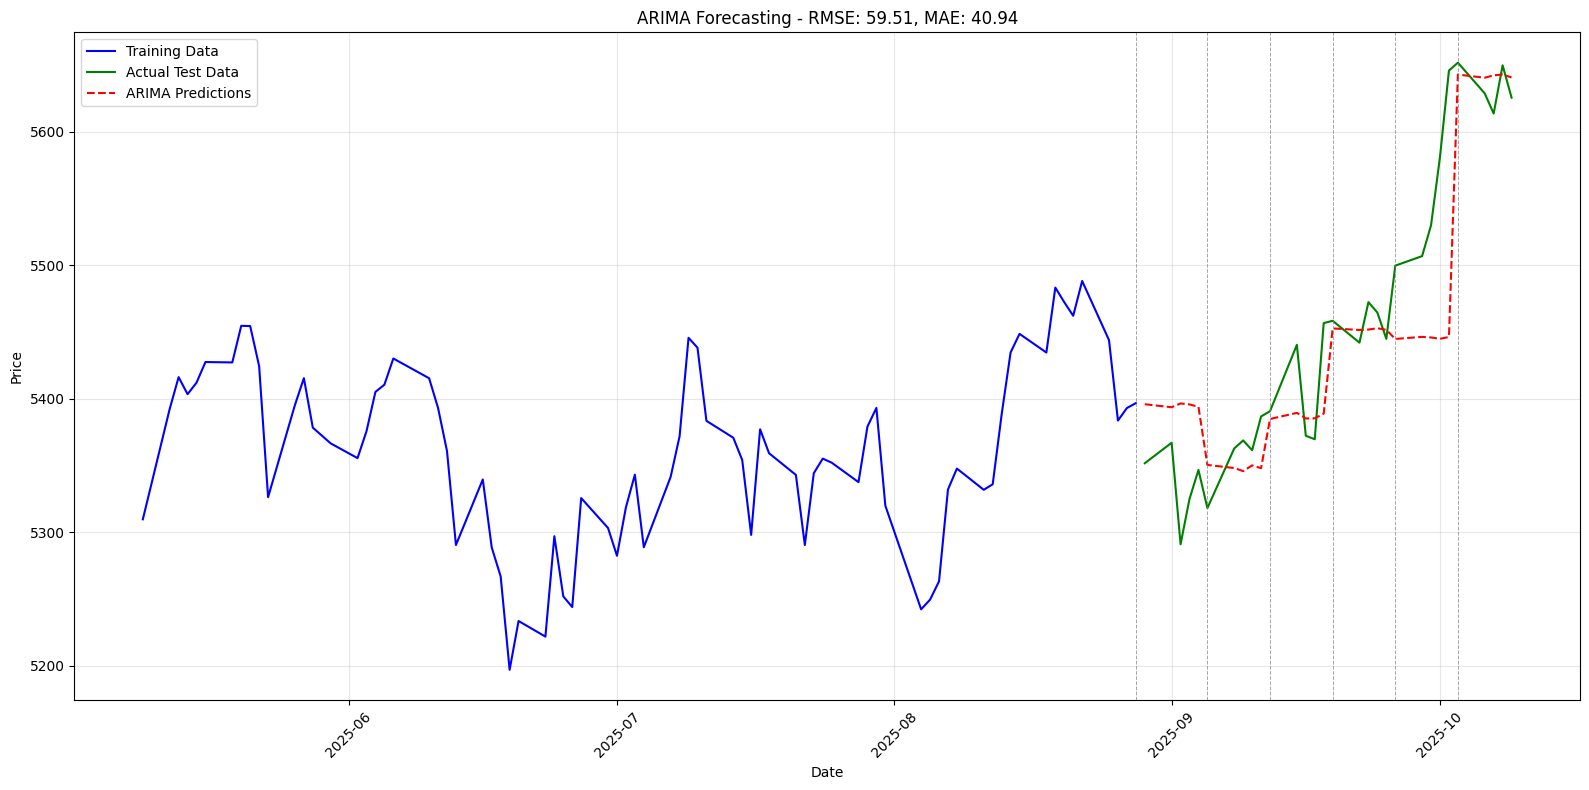

In [11]:
# ===================
# 9. VISUALIZATION 
# ===================

print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

# Determine date range for last 5 months (matching LSTM code)
end_date_plot = test_ts.index.max()
start_date_plot = end_date_plot - pd.DateOffset(months=5)

# Filter data for plotting (using DataFrame format to match LSTM code)
# Convert Series to DataFrame for consistency
train_data_plot = pd.DataFrame({'STOXX50_Close': train_ts})
train_data_plot = train_data_plot[train_data_plot.index >= start_date_plot]

actual_test_data_plot = pd.DataFrame({'STOXX50_Close': test_ts})
actual_test_data_plot = actual_test_data_plot[actual_test_data_plot.index >= start_date_plot]

predicted_data_plot = comparison_df[comparison_df.index >= start_date_plot]

# Create plot (matching LSTM style)
plt.figure(figsize=(16, 8))

# Plot training data (blue)
plt.plot(train_data_plot.index, train_data_plot['STOXX50_Close'], 
         label='Training Data', color='blue', linewidth=1.5)

# Plot actual test data (green)
plt.plot(actual_test_data_plot.index, actual_test_data_plot['STOXX50_Close'], 
         label='Actual Test Data', color='green', linewidth=1.5)

# Plot ARIMA predictions (red dashed) - matching LSTM style
plt.plot(predicted_data_plot.index, predicted_data_plot['ARIMA_Predicted'], 
         label='ARIMA Predictions', color='red', linestyle='--', linewidth=1.5)

# Add vertical line for train-test split (matching LSTM style)
plt.axvline(x=train_ts.index[-1], color='gray', 
            linestyle='--', linewidth=0.7, alpha=0.7)

# Add block boundaries (matching LSTM style)
for i in range(1, num_blocks):
    block_boundary = test_ts.index[i * forecast_horizon]
    plt.axvline(x=block_boundary, color='gray', linestyle='--', 
                alpha=0.7, linewidth=0.7)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'ARIMA Forecasting - RMSE: {rmse:.2f}, MAE: {mae:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()